# Testing our equation to La Jara data 

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error
import itertools

### Model Functions

From K iterations (original sigmoid), the best A and B parameters in the field were: 
- $A = 4.92 \times 10^{-5}$
- $B = 3.06$
- $\tau_{c,\min} = 0.07$

In [2]:
def evolve_tauc_tc(
    tau_star,           # array of Shields stress τ*(t)
    dt,                 # timestep between τ* samples
    tau_c_min,          # minimum τ*c global
    tau_c_max,          # maximum τ*c global
    event_indices,      # time labels or integer positions where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    multiplicative_factor=1, # factor to adjust k values (e.g., for sensitivity testing)
    A=4.92*10**(-5),
    B=3.06,
    ks=50, # sigmoid k_strengthening
    xs=0.79, # sigmoid x_shift (tc/tc_eq at inflection point)
    kw=3.7 # sigmoid k_weakening
):

    # convert τ* to numeric 1D array and keep index if Series
    if isinstance(tau_star, pd.Series):
        tau_index = tau_star.index
        tau_star_vals = tau_star.to_numpy(dtype=float)
    else:
        tau_index = None
        tau_star_vals = np.asarray(tau_star, dtype=float)

    if tau_star_vals.ndim != 1:
        raise ValueError("tau_star must be 1D after conversion")

    # convert event indices to integer positions in tau_star_vals
    event_labels = np.asarray(event_indices)
    if tau_index is not None:
        event_pos = tau_index.get_indexer(event_labels)

        # allow an initialization observation before forcing starts (e.g., event 0 while tau index starts at 1)
        missing_mask = event_pos < 0
        if np.any(missing_mask) and np.issubdtype(event_labels.dtype, np.number):
            before_start = missing_mask & (event_labels < tau_index.min())
            event_pos[before_start] = 0

        if np.any(event_pos < 0):
            missing_labels = event_labels[event_pos < 0]
            raise ValueError(f"some event indices are not in tau_star index: {missing_labels}")
    else:
        event_pos = np.asarray(event_indices, dtype=int)

    # keep only observed τ*c values that are not NaN
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)
    valid_obs_mask = ~np.isnan(tau_c_obs_arr)
    event_pos_valid = event_pos[valid_obs_mask]
    tau_c_obs_valid = tau_c_obs_arr[valid_obs_mask]

    # initialize modeled τ*c, τ*c_eq, and k array
    n = len(tau_star_vals)
    tau_c = np.full(n, np.nan, dtype=float)  # nan means τ*c is undefined (e.g., during gaps)
    tau_c_pot = np.full(n, np.nan, dtype=float)
    k_array = np.full(n, np.nan, dtype=float)
    tauc_ratio = np.full(n, np.nan, dtype=float)
    tau_conv_array = np.full(n, np.nan, dtype=float)

    tau_c_obs_dict = dict(zip(event_pos_valid, tau_c_obs_valid))
    was_in_gap = True

    i = 0
    while i < n-1:
        # determine current τ*
        t = tau_star_vals[i]  # current τ*

        # k equation parameters from flume data
        k = A * (t / tau_c_max) ** B

        # initialize τ*c when observation exists
        if was_in_gap and i in tau_c_obs_dict:
            tau_c_current = tau_c_obs_dict[i]
            tau_c[i] = tau_c_current
            was_in_gap = False
        else:
            tau_c_current = tau_c[i]

        # calculate transport capacity 
        tc = t/tau_c_current  # transport capacity
        tauc_ratio[i] = tc

        # calculate potential τ*c based on current τ*/τ*c
        if tc <= 1:
            sigmoid_0 = 1 / (1 + np.exp(-ks * (0 - xs)))
            sigmoid_1 = 1 / (1 + np.exp(-ks * (1 - xs)))
            sigmoig_tc = 1 / (1 + np.exp(-ks * (tc - xs)))
            sigmoid = (sigmoig_tc - sigmoid_0) / (sigmoid_1 - sigmoid_0)
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) * sigmoid 
            tau_pot = max(tau_c_current, tau_conv)  # τ*c cannot decrease below current value if τ* is low
            tau_pot_pure = tau_conv
        else:  # otherwise, equilibrium is given by the weakening function
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) * (tc) ** (-kw)
            tau_pot = tau_conv
            tau_pot_pure = tau_conv

        k_array[i] = k
        tau_c_pot[i] = tau_pot_pure
        tau_conv_array[i] = tau_pot

        # evolve τ*c with new equation
        tau_c[i+1] = tau_conv_array[i] - (tau_conv_array[i] - tau_c[i]) * np.exp(-k * multiplicative_factor * dt)
        #print('tauc at time:', i, 'is', tau_c[i], '. tau/tauc', tauc_ratio[i], 'and tau_pot is', tau_c_pot[i], 'with k', k_array[i])
        i += 1

    return tau_c, k_array, tau_c_pot, tauc_ratio

parameter calibration 

In [3]:
def calibrate_parameters(
    tau_star,
    event_indices,      # indices of event start times
    tau_c_obs,          # observed τ*c at events
    dt,
    tau_c_max,
    tau_c_min,
    ks_vals,             # candidate values for parameter ks
    xs_vals,             # candidate values for parameter xs
    kw_vals              # candidate values for parameter kw
):
    
    """
    Grid-search calibration of the model using mean absolute error (MAE).
    """
    results = []
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)
    
    # iterate through minimum τ*c values, and A and B parameters
    for ks_idx, A in enumerate(ks_vals):
        print(f"Testing ks = {A:.6e} ({ks_idx + 1}/{len(ks_vals)})")
        for xs_idx, B in enumerate(xs_vals):
            print(f"Testing xs = {B:.6e} ({xs_idx + 1}/{len(xs_vals)})")
            for kw_idx, C in enumerate(kw_vals):
                print(f"Testing kw = {C:.6e} ({kw_idx + 1}/{len(kw_vals)})")
                tau_c_model, *_ = evolve_tauc_tc(
                    tau_star=tau_star,
                    dt=dt,
                    tau_c_min=tau_c_min,
                    tau_c_max=tau_c_max,
                    event_indices=event_indices,
                    tau_c_obs=tau_c_obs,
                    ks=ks_vals[ks_idx],
                    xs=xs_vals[xs_idx],
                    kw=kw_vals[kw_idx]
                )

                # extract modeled τ*c at event starts
                if isinstance(tau_star, pd.Series):
                    tau_c_series = pd.Series(tau_c_model, index=tau_star.index)
                    tau_c_pred = tau_c_series.reindex(event_indices).to_numpy(dtype=float)
                else:
                    event_pos = np.asarray(event_indices, dtype=int)
                    tau_c_pred = np.asarray(tau_c_model, dtype=float)[event_pos]

                # calculate mean absolute error (paper uses MAE), and ignore NaNs
                mae = np.nanmean(np.abs(tau_c_pred - tau_c_obs_arr))
                results.append({
                    "ks": ks_vals[ks_idx],
                    "xs": xs_vals[xs_idx],
                    "kw": kw_vals[kw_idx],
                    "MAE": mae
                })

    expected = len(ks_vals) * len(xs_vals) * len(kw_vals)
    if len(results) != expected:
        raise RuntimeError(f"Expected {expected} calibration rows, got {len(results)}")

    return results

### Testing Field Data

Import Data

In [4]:
# import data 
tau_star = pd.read_csv('../../../shear_stress_record/average_shear_stress_lajara_full.csv')
tauc_events = pd.read_csv('../field_data/tauc_events_exceedance_rising.csv', parse_dates=['datetime'], index_col='datetime')
# convert to datetime and set as index
tau_star['datetime'] = pd.to_datetime(tau_star['datetime']) 
tau_star = tau_star.set_index('datetime')

# change column name to 'tau' for clarity
df_tau_resampled = tau_star.rename(columns={'shear_stress': 'tau'})
# delete everything before 2022-07-14 (we don't care about earlier times)
df_tau_resampled = df_tau_resampled[df_tau_resampled.index >= '2022-07-14 15:00']

print(f"Data gaps (NaNs): {df_tau_resampled['tau'].isna().sum().sum()}")
# show what dates are the data gaps
print("Data gaps (NaN indices):", df_tau_resampled[df_tau_resampled['tau'].isna()].index)

# convert tau to dimenstionless Shields stress τ*
rho_s = 2650.0  # sediment density, kg/m3
rho = 1000.0   # fluid density, kg/m3
g = 9.81       # gravitational acceleration, m/s2
d50 = 0.04364    # median grain diameter, m

df_tau_resampled['tau_star'] = df_tau_resampled['tau'] / ((rho_s - rho) * g * d50)

# build integer index mapping
time_to_index = pd.Series(
    np.arange(len(df_tau_resampled)), 
    index=df_tau_resampled.index
)
event_indices = time_to_index.loc[tauc_events.index].to_numpy() # integer indices of event times
tau_c_obs = tauc_events["tauc"].to_numpy() # observed τ*c values
tau_star = df_tau_resampled["tau_star"].to_numpy() # τ* time series array

# calculate dt in minutes (should be 15)
dt = (df_tau_resampled.index[1] - df_tau_resampled.index[0]).total_seconds() / 60
print(f"Calculated dt: {dt} minutes")

Data gaps (NaNs): 0
Data gaps (NaN indices): DatetimeIndex([], dtype='datetime64[ns]', name='datetime', freq=None)
Calculated dt: 15.0 minutes


### First Iteration

In [5]:
tauc_obs_lajara = tauc_events["tauc"].to_numpy()
# start, stop, number of values
ks_vals = np.geomspace(0.1, 20, 20) # values evenly spaced on log scale
xs_vals = np.linspace(-1, 1, 20) 
kw_vals = np.geomspace(0.1, 5, 20) # values evenly spaced on linear scale
tauc_max_lajara = 0.14254
tauc_min_lajara = 0.07

In [7]:
calibration = calibrate_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=15,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    ks_vals=ks_vals,
    kw_vals=kw_vals,
    xs_vals=xs_vals
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing ks = 1.000000e-01 (1/20)
Testing xs = -1.000000e+00 (1/20)
Testing kw = 1.000000e-01 (1/20)
Testing kw = 1.228625e-01 (2/20)
Testing kw = 1.509520e-01 (3/20)
Testing kw = 1.854635e-01 (4/20)
Testing kw = 2.278651e-01 (5/20)
Testing kw = 2.799609e-01 (6/20)
Testing kw = 3.439671e-01 (7/20)
Testing kw = 4.226066e-01 (8/20)
Testing kw = 5.192252e-01 (9/20)
Testing kw = 6.379333e-01 (10/20)
Testing kw = 7.837810e-01 (11/20)
Testing kw = 9.629732e-01 (12/20)
Testing kw = 1.183133e+00 (13/20)
Testing kw = 1.453628e+00 (14/20)
Testing kw = 1.785964e+00 (15/20)
Testing kw = 2.194280e+00 (16/20)
Testing kw = 2.695948e+00 (17/20)
Testing kw = 3.312311e+00 (18/20)
Testing kw = 4.069589e+00 (19/20)
Testing kw = 5.000000e+00 (20/20)
Testing xs = -8.947368e-01 (2/20)
Testing kw = 1.000000e-01 (1/20)
Testing kw = 1.228625e-01 (2/20)
Testing kw = 1.509520e-01 (3/20)
Testing kw = 1.854635e-01 (4/20)
Testing kw = 2.278651e-01 (5/20)
Testing kw = 2.799609e-01 (6/20)
Testing kw = 3.439671e-01 (7/2

Plot

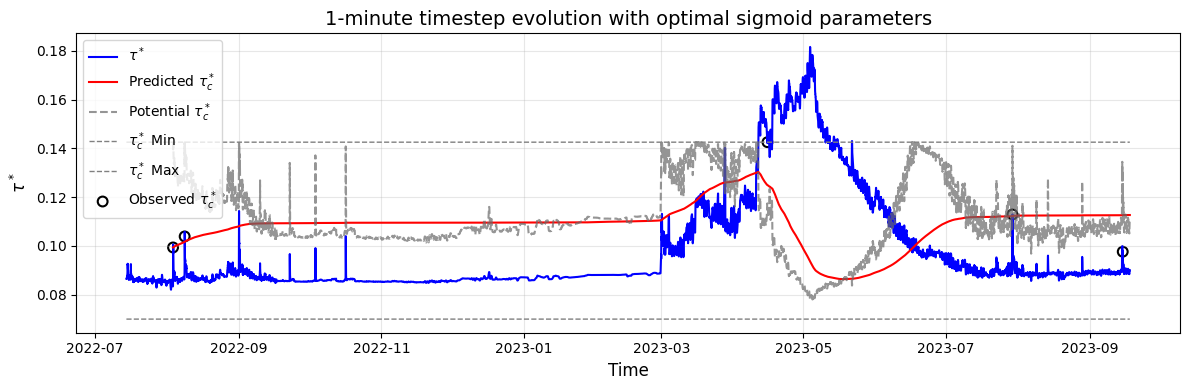

In [11]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=15, # 1 minute timestep
    tau_c_min=tauc_min_lajara,
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    ks=best["ks"],
    xs=best["xs"],
    kw=best["kw"]
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [tauc_min_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("1-minute timestep evolution with optimal sigmoid parameters", fontsize=14)

plt.tight_layout()
plt.show()

Best MAE: 0.007109
10% threshold (<=): 0.008531
Parameter sets within threshold: 104 / 8000

Top 30 by MAE:


,MAE,ks,xs,kw
0,0.007109,20.000000,0.789474,3.312311
1,0.007370,15.132935,0.789474,3.312311
2,0.007549,11.450285,0.789474,3.312311
3,0.007643,8.663821,0.789474,3.312311
4,0.007683,6.555452,0.789474,3.312311
5,0.007786,20.000000,0.789474,4.069589
6,0.007801,15.132935,0.684211,4.069589
7,0.007853,3.753090,0.894737,3.312311
8,0.007869,8.663821,0.894737,2.695948
9,0.007876,6.555452,0.894737,2.695948


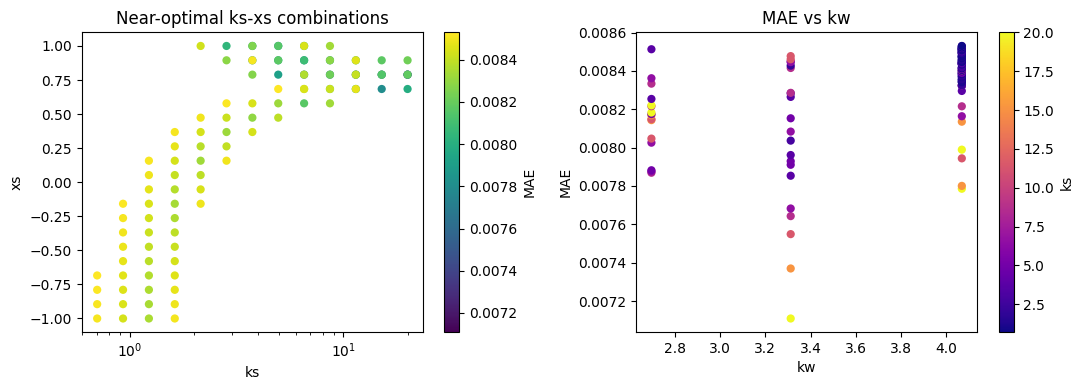

In [12]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)
mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.2

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "dt=15/sigmoid_params_iteration1.csv"
near_optimal.to_csv(out_path, index=False)

# quick visualization of the near-optimal parameter cloud (if expected columns exist).
if {"ks", "xs", "kw"}.issubset(near_optimal.columns):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sc1 = axes[0].scatter(
        near_optimal["ks"],
        near_optimal["xs"],
        c=near_optimal[mae_col],
        cmap="viridis",
        s=35,
        edgecolors="none",
    )
    axes[0].set_xscale("log")
    axes[0].set_xlabel("ks")
    axes[0].set_ylabel("xs")
    axes[0].set_title("Near-optimal ks-xs combinations")
    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label(mae_col)

    sc2 = axes[1].scatter(
        near_optimal["kw"],
        near_optimal[mae_col],
        c=near_optimal["ks"],
        cmap="plasma",
        s=35,
        edgecolors="none",
    )
    axes[1].set_xlabel("kw")
    axes[1].set_ylabel(mae_col)
    axes[1].set_title("MAE vs kw")
    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("ks")

    plt.tight_layout()
    plt.show()

### Second Iteration

Changing A and b as well! 
- $\tau_{c,\min} = 0.07$
- $\tau_{c,\min} = 0.14254$

In [16]:
def calibrate_all_parameters(
    tau_star,
    event_indices,      # indices of event start times
    tau_c_obs,          # observed τ*c at events
    dt,
    tau_c_max,
    tau_c_min,
    A_vals,              # candidate values for parameter A
    B_vals,              # candidate values for parameter B
    ks_vals,             # candidate values for parameter ks
    xs_vals,             # candidate values for parameter xs
    kw_vals              # candidate values for parameter kw
):
    
    """
    Grid-search calibration of the model using mean absolute error (MAE).
    """
    results = []
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)
    
    # iterate through all iterable parameters
    for A_idx, A in enumerate(A_vals):
        print(f"Testing A = {A:.6e} ({A_idx + 1}/{len(A_vals)})")
        for B_idx, B in enumerate(B_vals):
            print(f"Testing B = {B:.6e} ({B_idx + 1}/{len(B_vals)})")
            for ks_idx, ks in enumerate(ks_vals):
                print(f"Testing ks = {ks:.6e} ({ks_idx + 1}/{len(ks_vals)})")
                for xs_idx, xs in enumerate(xs_vals):
                    print(f"Testing xs = {xs:.6e} ({xs_idx + 1}/{len(xs_vals)})")
                    for kw_idx, kw in enumerate(kw_vals):
                        print(f"Testing kw = {kw:.6e} ({kw_idx + 1}/{len(kw_vals)})")
                        tau_c_model, *_ = evolve_tauc_tc(
                            tau_star=tau_star,
                            dt=dt,
                            tau_c_min=tau_c_min,
                            tau_c_max=tau_c_max,
                            event_indices=event_indices,
                            tau_c_obs=tau_c_obs,
                            A=A_vals[A_idx],
                            B=B_vals[B_idx],
                            ks=ks_vals[ks_idx],
                            xs=xs_vals[xs_idx],
                            kw=kw_vals[kw_idx]
                        )

                        # extract modeled τ*c at event starts
                        if isinstance(tau_star, pd.Series):
                            tau_c_series = pd.Series(tau_c_model, index=tau_star.index)
                            tau_c_pred = tau_c_series.reindex(event_indices).to_numpy(dtype=float)
                        else:
                            event_pos = np.asarray(event_indices, dtype=int)
                            tau_c_pred = np.asarray(tau_c_model, dtype=float)[event_pos]

                        # calculate mean absolute error (paper uses MAE), and ignore NaNs
                        mae = np.nanmean(np.abs(tau_c_pred - tau_c_obs_arr))
                        results.append({
                            "A" : A_vals[A_idx],
                            "B" : B_vals[B_idx],
                            "ks": ks_vals[ks_idx],
                            "xs": xs_vals[xs_idx],
                            "kw": kw_vals[kw_idx],
                            "MAE": mae
                        })

    expected = len(A_vals) * len(B_vals) * len(ks_vals) * len(xs_vals) * len(kw_vals)
    if len(results) != expected:
        raise RuntimeError(f"Expected {expected} calibration rows, got {len(results)}")

    return results

In [17]:
tauc_obs_lajara = tauc_events["tauc"].to_numpy()
# start, stop, number of values
A_vals = np.linspace(1e-6, 1e-4, 10) # values evenly spaced on linear scale
B_vals = np.linspace(1, 20, 10) # values evenly spaced on linear scale
ks_vals = np.linspace(1, 80, 10) # values evenly spaced on linear scale
xs_vals = np.linspace(0, 1, 10) # values evenly spaced on linear scale
kw_vals = np.linspace(0, 8, 10) # values evenly spaced on linear scale

tauc_max_lajara = 0.14254
tauc_min_lajara = 0.07

In [18]:
calibration = calibrate_all_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=15,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
    ks_vals=ks_vals,
    kw_vals=kw_vals,
    xs_vals=xs_vals
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

Testing A = 1.000000e-06 (1/10)
Testing B = 1.000000e+00 (1/10)
Testing ks = 1.000000e+00 (1/10)
Testing xs = 0.000000e+00 (1/10)
Testing kw = 0.000000e+00 (1/10)
Testing kw = 8.888889e-01 (2/10)
Testing kw = 1.777778e+00 (3/10)
Testing kw = 2.666667e+00 (4/10)
Testing kw = 3.555556e+00 (5/10)
Testing kw = 4.444444e+00 (6/10)
Testing kw = 5.333333e+00 (7/10)
Testing kw = 6.222222e+00 (8/10)
Testing kw = 7.111111e+00 (9/10)
Testing kw = 8.000000e+00 (10/10)
Testing xs = 1.111111e-01 (2/10)
Testing kw = 0.000000e+00 (1/10)
Testing kw = 8.888889e-01 (2/10)
Testing kw = 1.777778e+00 (3/10)
Testing kw = 2.666667e+00 (4/10)
Testing kw = 3.555556e+00 (5/10)
Testing kw = 4.444444e+00 (6/10)
Testing kw = 5.333333e+00 (7/10)
Testing kw = 6.222222e+00 (8/10)
Testing kw = 7.111111e+00 (9/10)
Testing kw = 8.000000e+00 (10/10)
Testing xs = 2.222222e-01 (3/10)
Testing kw = 0.000000e+00 (1/10)
Testing kw = 8.888889e-01 (2/10)
Testing kw = 1.777778e+00 (3/10)
Testing kw = 2.666667e+00 (4/10)
Testing kw

Plot

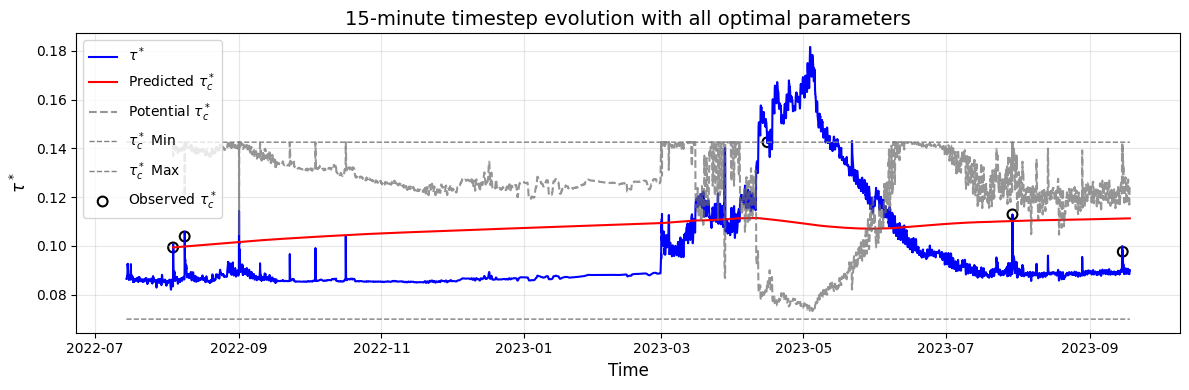

In [19]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=tauc_min_lajara,
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
    ks=best["ks"],
    xs=best["xs"],
    kw=best["kw"]
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [tauc_min_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("15-minute timestep evolution with all optimal parameters", fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)
mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.2

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "dt=15/sigmoid_params_iteration2.csv"
near_optimal.to_csv(out_path, index=False)

### Third Iteration

Changing A, b, ks, xs and kw. 
Using tau_c min as the minimum tau_c that we measured
- $\tau_{c,\min} = 0.095$
- $\tau_{c,\min} = 0.14254$

In [ ]:
tauc_obs_lajara = tauc_events["tauc"].to_numpy()
# start, stop, number of values
A_vals = np.linspace(1e-6, 1e-4, 10) # values evenly spaced on linear scale
B_vals = np.linspace(1, 20, 10) # values evenly spaced on linear scale
ks_vals = np.linspace(1, 80, 10) # values evenly spaced on linear scale
xs_vals = np.linspace(0, 1, 10) # values evenly spaced on linear scale
kw_vals = np.linspace(0, 8, 10) # values evenly spaced on linear scale

tauc_max_lajara = 0.14254
tauc_min_lajara = 0.095

In [ ]:
calibration = calibrate_all_parameters(
    tau_star,
    event_indices,
    tauc_obs_lajara,
    dt=1,
    tau_c_max=tauc_max_lajara,
    tau_c_min=tauc_min_lajara,
    A_vals=A_vals,
    B_vals=B_vals,
    ks_vals=ks_vals,
    kw_vals=kw_vals,
    xs_vals=xs_vals
)
best = min(calibration, key=lambda x: x["MAE"])
print("Best-fit parameters:")
print(best)

In [ ]:
tauc_lajara, k_lajara, tauc_pot_lajara, tauc_ratio_lajara = evolve_tauc_tc(
    tau_star,
    dt=1, # 1 minute timestep
    tau_c_min=tauc_min_lajara,
    tau_c_max=tauc_max_lajara,
    event_indices=event_indices,
    tau_c_obs=tauc_obs_lajara,
    A=best["A"],
    B=best["B"],
    ks=best["ks"],
    xs=best["xs"],
    kw=best["kw"]
)

tau_c_pred_series = pd.Series(tauc_lajara, index=time_to_index.index)
tau_star_series = pd.Series(tau_star, index=time_to_index.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tauc_pot_lajara, color='dimgrey', linestyle='--', label=r'Potential $\tau_c^*$', linewidth=1.5, alpha=0.7)
# horizontal min and max lines
ax.plot(tau_c_pred_series.index, [tauc_min_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Min', linewidth=1)
ax.plot(tau_c_pred_series.index, [tauc_max_lajara]*len(tau_c_pred_series), color='gray', linestyle='--', label=r'$\tau_c^*$ Max', linewidth=1)
# plot measured tauc calibration points
obs_tauc_series = pd.Series(tauc_obs_lajara, index=tauc_events.index)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=50, linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("15-minute timestep evolution with all optimal parameters", fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
# sensitivity filter: keep parameter sets within 10% of the best MAE
calibration_df = pd.DataFrame(calibration)
mae_candidates = [c for c in calibration_df.columns if "mae" in c.lower()]
if not mae_candidates:
    raise ValueError(f"No MAE-like column found in calibration results. Columns: {list(calibration_df.columns)}")
mae_col = mae_candidates[0]

best_mae = calibration_df[mae_col].min()
mae_threshold = best_mae * 1.2

near_optimal = (
    calibration_df.loc[calibration_df[mae_col] <= mae_threshold]
    .sort_values(mae_col)
    .reset_index(drop=True)
)

print(f"Best MAE: {best_mae:.6f}")
print(f"10% threshold (<=): {mae_threshold:.6f}")
print(f"Parameter sets within threshold: {len(near_optimal)} / {len(calibration_df)}")

# show top candidates and all near-optimal rows.
cols_priority = [c for c in ["tau_c_min", "A", "B", mae_col] if c in near_optimal.columns]
other_cols = [c for c in near_optimal.columns if c not in cols_priority]
near_optimal = near_optimal[cols_priority + other_cols]

if len(near_optimal) > 30:
    print("\nTop 30 by MAE:")
    display(near_optimal.head(30))
else:
    display(near_optimal)

# save full near-optimal set for later analysis.
out_path = "dt=15/sigmoid_params_iteration3.csv"
near_optimal.to_csv(out_path, index=False)